<a href="https://colab.research.google.com/github/AndreiDragomir07/COS484_A3/blob/main/Andrei_Dragomir_Neural_Machine_Translation_(COS484_S2026).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook for Programming in Problem 3
Welcome to the programming portion of the assignment! Each assignment throughout the semester will have a written portion and a programming portion. We will be using [Google Colab](https://colab.research.google.com/notebooks/intro.ipynb#recent=true), so if you have never used it before, take a quick look through this introduction: [Working with Google Colab](https://docs.google.com/document/d/1LlnXoOblXwW3YX-0yG_5seTXJsb3kRdMMRYqs8Qqum4/edit?usp=sharing).

## Learning Objectives
In this problem, we will use [PyTorch](https://pytorch.org/) to implement a sequence-to-sequence (seq2seq) transformer model to build a nerual machine translation (NMT) system, which translates from French to English.

## Installing Packages

Install PyTorch using pip. See [https://pytorch.org/](https://pytorch.org/) if you want to install it on your computer.
In addition, we will also be needing [huggingface](https://huggingface.co/)'s `transformers` and `datasets` libraries, and [nltk](https://www.nltk.org/) to compute the BLEU score.

In [3]:
pip install torch transformers datasets nltk

## Download NMT data

You need to first download and then unzip the data for NMT, which contains pairs of parallel sentences from the link below:
* Resources: https://princeton-nlp.github.io/cos484/assignments/a3/resources.zip

In [4]:
import os

DATA_URL = "https://princeton-nlp.github.io/cos484/assignments/a3/resources.zip"
ZIP_FILE_NAME = "resources.zip"
EXTRACT_DIR = "./nmt_data"

os.makedirs(EXTRACT_DIR, exist_ok=True)

print(f"Downloading data from {DATA_URL}...")
!wget -O {ZIP_FILE_NAME} {DATA_URL}

print(f"Unzipping {ZIP_FILE_NAME} to {EXTRACT_DIR}...")
!unzip -o {ZIP_FILE_NAME} -d {EXTRACT_DIR}

print("Download and extraction complete.")

print(f"Contents of {EXTRACT_DIR}:")
!ls {EXTRACT_DIR}

--2026-03-31 00:52:41--  https://princeton-nlp.github.io/cos484/assignments/a3/resources.zip
Resolving princeton-nlp.github.io (princeton-nlp.github.io)... 185.199.109.153, 185.199.110.153, 185.199.108.153, ...
Connecting to princeton-nlp.github.io (princeton-nlp.github.io)|185.199.109.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 257538 (252K) [application/x-zip-compressed]
Saving to: ‘resources.zip’

resources.zip       100%[===================>] 251.50K  --.-KB/s    in 0.01s   

2026-03-31 00:52:41 (19.8 MB/s) - ‘resources.zip’ saved [257538/257538]

Unzipping resources.zip to ./nmt_data...
Archive:  resources.zip
   creating: ./nmt_data/resources/
   creating: ./nmt_data/resources/parallel_en_fr_corpus/
  inflating: ./nmt_data/resources/parallel_en_fr_corpus/dataset_dict.json  
   creating: ./nmt_data/resources/parallel_en_fr_corpus/test/
  inflating: ./nmt_data/resources/parallel_en_fr_corpus/test/dataset.arrow  
  inflating: ./nmt_data/resources/pa

## Data Loading and Tokenization
You will need to write code to load and tokenize the data for NMT.


The parallel data `parallel_en_fr_corpus` is provided as huggingface datasets, one for each split of `train`, `validation` and `test`. You can load it via the `load_from_disk` method and inspect its features. If you'd like to know more about these dataset objects, have a look at [this tutorial](https://huggingface.co/docs/datasets/access).

In [5]:
from datasets import load_from_disk

train_dataset = load_from_disk("./nmt_data/resources/parallel_en_fr_corpus/train")
val_dataset = load_from_disk("./nmt_data/resources/parallel_en_fr_corpus/validation")
test_dataset = load_from_disk("./nmt_data/resources/parallel_en_fr_corpus/test")

print(train_dataset["text_fr"][0:9])

['je suis dure .', 'je ne suis pas aux pieces .', 'je ne dors pas bien .', 'c est mon associe .', 'tu es idiote .', 'nous sommes engagees .', 'c est pour vous que je suis venu .', 'c est une enfant apres tout .', 'je suis a ton service .']


You are also provided with two pre-trained tokenizers for the source and target languages, `tokenizer_fr` and `tokenizer_en`, respectively, which can be loaded with the hugginface transformers library. [This tutorial](https://huggingface.co/docs/transformers/preprocessing#natural-language-processing) provides an introduction to using pre-trained tokenizers and the powerful `AutoTokenizer` class. The tokenizers are based on byte-pair encodings which break words into smaller units. This is aimed at reducing the sparsity of words, as subwords can be shared between different rare words. If you are interested in learning more, see the paper [Neural Machine Translation of Rare Words with Subword Units](https://www.aclweb.org/anthology/P16-1162.pdf).

In [6]:
from transformers import AutoTokenizer

english_tokenizer = AutoTokenizer.from_pretrained("./nmt_data/resources/tokenizer_en")
french_tokenizer = AutoTokenizer.from_pretrained("./nmt_data/resources/tokenizer_fr")


You should implement a function to convert the entire dataset to token ids.

In [7]:
def tokenize_function(examples):
    # Tokenize the French (source) text
    model_inputs = french_tokenizer(examples["text_fr"], truncation=True, max_length=128)

    # Tokenize the English (target) text
    # We need to use `with_target_tokenizer` context for the labels
    labels = english_tokenizer(examples["text_en"], truncation=True, max_length=128)

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# Apply the tokenization function to all datasets
tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True, remove_columns=train_dataset.column_names)
tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True, remove_columns=val_dataset.column_names)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True, remove_columns=test_dataset.column_names)

print("Tokenized training dataset example:")
print(tokenized_train_dataset[323])
print("\nFeatures of the tokenized training dataset:")
print(tokenized_train_dataset.features)

Map:   0%|          | 0/8701 [00:00<?, ? examples/s]

Map:   0%|          | 0/485 [00:00<?, ? examples/s]

Map:   0%|          | 0/486 [00:00<?, ? examples/s]

Tokenized training dataset example:
{'input_ids': [1, 90, 46, 2528, 1377, 2158, 36, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1], 'labels': [1, 71, 1430, 795, 1139, 1441, 1424, 35, 2]}

Features of the tokenized training dataset:
{'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8')), 'labels': List(Value('int64'))}


Just an example of how to use the decoder to find the word based on an ID

In [8]:
from transformers import AutoTokenizer

english_tokenizer = AutoTokenizer.from_pretrained("./nmt_data/resources/tokenizer_en")

# Example token ID from the tokenized_train_dataset['labels'][323] which is [1, 71, 1430, 795, 1139, 1441, 1424, 35, 2]
# Let's take the token ID `71` as an example.
example_token_id = 71
decoded_word = english_tokenizer.decode(example_token_id)

print(f"The token ID {example_token_id} decodes to: '{decoded_word}'")

# You can also decode a list of token IDs
example_token_ids_list = [1, 71, 1430, 795, 1139, 1441, 1424, 35, 2] # This is the full 'labels' for the example
decoded_sentence = english_tokenizer.decode(example_token_ids_list, skip_special_tokens=True)

print(f"The list of token IDs {example_token_ids_list} decodes to: '{decoded_sentence}'")

The token ID 71 decodes to: '▁she'
The list of token IDs [1, 71, 1430, 795, 1139, 1441, 1424, 35, 2] decodes to: '▁she ▁suddenly ▁lost ▁cons cious ness ▁.'


## Transformer model for NMT

You should implement a encoder-decoder transformer model. This includes:
* **MultiHeadAttention Layers**: A class that initializes the multi-head attention layer and has a forward function to compute scaled dot-product attention and returns the output of the attention layer.
* **Embedding Layers**: A class that defines both the token embeddings and positional embeddings, which are added together to form the final embedding. This class should have functions to compute the logits for the next token prediction given the decoder output, and to compute the embeddings for the input tokens.
* **Transformer Blocks**: A class that defins a single Transformer block including the multi-head attention layers and feedforward layers, which can be either for the encoder or the decoder. This class should have a forward function that works either for the encoder or the decoder.
* **EncoderDecoderModel**: A class that defines a encoder-decoder transformer model which can be used for NMT.

For your MultiHeadAttention, your `MultiHeadAttention.forward()` should return a tuple of `(layer_output, attention_weights)`, where `attention_weights` has shape `(batch_size, num_heads, num_query_tokens, num_key_tokens)`. Your `forward_decoder()` should accept an optional flag `return_attention_weights: bool = False` and, when set to `True`, return the cross-attention weights from each decoder layer as a list of tensors in addition to the logits. You will need this to extract and visualize the cross-attention weights in Question (d).

For your EncoderDecoderModel, you can use these architecture hyperparameters without modifications:
* hidden_size: 32
* intermediate_size: 128 (32 * 4)
* num_attention_heads: 4
* num_encoder_layers: 3
* num_decoder_layers: 3
* max_sequence_length: 32
* hidden_dropout_prob: 0.1
* FFN activation: ReLU
* norm placement: post-norm
* attention weight dropout: none
* embedding dropout: none
* weight tying: none

### Embedder Class

First, we will implement the embedding class, which creates both normal and positional embeddings for both the encoder and the decoder as instantiations of nn.Module, in order for them to be updatable as part of the training process.

In [9]:
import torch
import torch.nn as nn

class EmbeddingData(nn.Module):
  def __init__(self, encoder_vocab_size,
               decoder_vocab_size, hidden_size, max_seq_length):
    super().__init__()

    self.hidden_size = hidden_size
    self.max_seq_length = max_seq_length

    # Token embeddings
    self.encoder_token_embedding = nn.Embedding(encoder_vocab_size, hidden_size)
    self.decoder_token_embedding = nn.Embedding(decoder_vocab_size, hidden_size)

    # Positional embeddings (learnable)
    self.encoder_pos_embedding = nn.Embedding(max_seq_length, hidden_size)
    self.decoder_pos_embedding = nn.Embedding(max_seq_length, hidden_size)

  def _get_pos_embeddings(self, seq_len, device):
      # Create position IDs from 0 to seq_len-1
      positions = torch.arange(0, seq_len, dtype=torch.long, device=device)
      return positions

  def encoder_embed(self, tokenized_examples):
      # tokenized_examples is expected to be a tensor of token IDs
      # shape: (batch_size, seq_len)
      seq_len = tokenized_examples.size(1)
      device = tokenized_examples.device

      if seq_len > self.max_seq_length:
          raise ValueError(f"Sequence length ({seq_len}) exceeds max_seq_length ({self.max_seq_length})")

      token_embeds = self.encoder_token_embedding(tokenized_examples)
      pos_embeds = self.encoder_pos_embedding(self._get_pos_embeddings(seq_len, device))

      # Add token and positional embeddings
      embeddings = token_embeds + pos_embeds
      return embeddings

  def decoder_embed(self, tokenized_examples):
      # tokenized_examples is expected to be a tensor of token IDs
      # shape: (batch_size, seq_len)
      seq_len = tokenized_examples.size(1)
      device = tokenized_examples.device

      if seq_len > self.max_seq_length:
          raise ValueError(f"Sequence length ({seq_len}) exceeds max_seq_length ({self.max_seq_length})")

      token_embeds = self.decoder_token_embedding(tokenized_examples)
      pos_embeds = self.decoder_pos_embedding(self._get_pos_embeddings(seq_len, device))

      # Add token and positional embeddings
      embeddings = token_embeds + pos_embeds
      return embeddings

# Hyperparameters from the problem description
hidden_size = 32
max_sequence_length = 32 # From problem description
encoder_vocab_size = french_tokenizer.vocab_size
decoder_vocab_size = english_tokenizer.vocab_size # Corrected variable name

embedding = EmbeddingData(encoder_vocab_size, decoder_vocab_size, hidden_size, max_sequence_length)

print(f"EmbeddingData initialized with:\n"
      f"  Encoder Vocab Size: {encoder_vocab_size}\n"
      f"  Decoder Vocab Size: {decoder_vocab_size}\n"
      f"  Hidden Size: {hidden_size}\n"
      f"  Max Sequence Length: {max_sequence_length}")

# Check if it's a proper nn.Module and has learnable parameters
print(f"Is EmbeddingData an nn.Module? {isinstance(embedding, nn.Module)}")
print(f"Number of learnable parameters in EmbeddingData: {sum(p.numel() for p in embedding.parameters() if p.requires_grad)}")

EmbeddingData initialized with:
  Encoder Vocab Size: 3200
  Decoder Vocab Size: 3200
  Hidden Size: 32
  Max Sequence Length: 32
Is EmbeddingData an nn.Module? True
Number of learnable parameters in EmbeddingData: 206848


In [10]:
print(f"English tokenizer vocabulary size: {english_tokenizer.vocab_size}")
print(f"French tokenizer vocabulary size: {french_tokenizer.vocab_size}")

English tokenizer vocabulary size: 3200
French tokenizer vocabulary size: 3200


### Multi-head attention layer class

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttentionLayer(nn.Module):
  def __init__(self, hidden_size, num_attention_heads):
    super().__init__()

    if hidden_size % num_attention_heads != 0:
      raise ValueError(
          f"hidden_size ({hidden_size}) should be divisible by num_attention_heads ({num_attention_heads})"
      )

    self.hidden_size = hidden_size
    self.num_heads = num_attention_heads
    self.head_dim = hidden_size // num_attention_heads

    self.q_proj = nn.Linear(hidden_size, hidden_size)
    self.k_proj = nn.Linear(hidden_size, hidden_size)
    self.v_proj = nn.Linear(hidden_size, hidden_size)
    self.out_proj = nn.Linear(hidden_size, hidden_size)

  def _split_heads(self, x, batch_size):
    """Splits the last dimension into (num_heads, head_dim)."""
    x = x.view(batch_size, -1, self.num_heads, self.head_dim)
    return x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, head_dim)

  def _combine_heads(self, x, batch_size):
    """Combines heads back to original hidden_size dimension."""
    x = x.permute(0, 2, 1, 3).contiguous()
    return x.view(batch_size, -1, self.hidden_size) # (batch_size, seq_len, hidden_size)

  def forward(self, query, key, value, mask=None):
    batch_size = query.size(0)

    # 1. Project Q, K, V
    q = self.q_proj(query)
    k = self.k_proj(key)
    v = self.v_proj(value)

    # 2. Split into multiple heads
    q = self._split_heads(q, batch_size)
    k = self._split_heads(k, batch_size)
    v = self._split_heads(v, batch_size)

    # 3. Scaled Dot-Product Attention
    # (batch_size, num_heads, query_seq_len, head_dim) @ (batch_size, num_heads, head_dim, key_seq_len)
    #   -> (batch_size, num_heads, query_seq_len, key_seq_len)
    attention_scores = torch.matmul(q, k.transpose(-2, -1)) / (self.head_dim**0.5)

    if mask is not None:
      # Apply mask by filling -inf for masked positions
      # Mask shape: (batch_size, 1, 1, key_seq_len) or (batch_size, 1, query_seq_len, key_seq_len)
      attention_scores = attention_scores.masked_fill(mask == 0, -1e9)

    attention_weights = F.softmax(attention_scores, dim=-1)

    # (batch_size, num_heads, query_seq_len, key_seq_len) @ (batch_size, num_heads, key_seq_len, head_dim)
    #   -> (batch_size, num_heads, query_seq_len, head_dim)
    attention_output = torch.matmul(attention_weights, v)

    # 4. Combine heads
    attention_output = self._combine_heads(attention_output, batch_size)

    # 5. Output projection
    layer_output = self.out_proj(attention_output)

    return layer_output, attention_weights

### Tranformer block implementation

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TransformerBlock(nn.Module):
  def __init__(self, hidden_size, num_attention_heads, intermediate_size, dropout_prob, is_decoder=False):
    super().__init__()
    self.is_decoder = is_decoder
    self.hidden_size = hidden_size

    # Self-Attention Layer
    self.self_attention = MultiHeadAttentionLayer(hidden_size, num_attention_heads)
    self.self_attention_output_dropout = nn.Dropout(dropout_prob)
    self.self_attention_layer_norm = nn.LayerNorm(hidden_size)

    # Cross-Attention Layer (only for decoder)
    if self.is_decoder:
      self.cross_attention = MultiHeadAttentionLayer(hidden_size, num_attention_heads)
      self.cross_attention_output_dropout = nn.Dropout(dropout_prob)
      self.cross_attention_layer_norm = nn.LayerNorm(hidden_size)

    # Feed-Forward Layer
    self.intermediate = nn.Linear(hidden_size, intermediate_size)
    self.output_layer = nn.Linear(intermediate_size, hidden_size)
    self.ffn_output_dropout = nn.Dropout(dropout_prob)
    self.ffn_layer_norm = nn.LayerNorm(hidden_size)
    self.activation = nn.ReLU() # FFN activation: ReLU as per problem description

  def forward(self, hidden_states, attention_mask=None, encoder_hidden_states=None, encoder_attention_mask=None, return_attention_weights=False):
    # Self-Attention Block
    # hidden_states is the input to the block.
    # Post-norm: Apply norm after addition

    # Layer 1: Self-Attention
    self_attention_output, self_attention_weights = self.self_attention(
        hidden_states, hidden_states, hidden_states, attention_mask
    )
    self_attention_output = self.self_attention_output_dropout(self_attention_output)
    # Add and Norm (Post-norm)
    hidden_states = self.self_attention_layer_norm(hidden_states + self_attention_output)

    cross_attention_weights = None
    if self.is_decoder and encoder_hidden_states is not None and encoder_attention_mask is not None:
      # Layer 2: Cross-Attention (Decoder only)
      cross_attention_output, cross_attention_weights = self.cross_attention(
          hidden_states, encoder_hidden_states, encoder_hidden_states, encoder_attention_mask
      )
      cross_attention_output = self.cross_attention_output_dropout(cross_attention_output)
      # Add and Norm (Post-norm)
      hidden_states = self.cross_attention_layer_norm(hidden_states + cross_attention_output)

    # Layer 3: Feed-Forward Network
    ffn_output = self.intermediate(hidden_states)
    ffn_output = self.activation(ffn_output)
    ffn_output = self.output_layer(ffn_output)
    ffn_output = self.ffn_output_dropout(ffn_output)
    # Add and Norm (Post-norm)
    hidden_states = self.ffn_layer_norm(hidden_states + ffn_output)

    if return_attention_weights and self.is_decoder:
      # Only return cross-attention weights for decoder when requested
      return hidden_states, cross_attention_weights

    return hidden_states

--- Toy Example for MultiHeadAttentionLayer ---

--- Encoder Self-Attention ---
Toy Encoder Input Shape: torch.Size([2, 10, 32])
Toy Encoder Self-Attention Output Shape: torch.Size([2, 10, 32])
Toy Encoder Self-Attention Weights Shape: torch.Size([2, 4, 10, 10])
Encoder Padding Mask (first batch item): [ True  True  True  True  True  True  True  True  True False]
Encoder self-attention outputs generated successfully.


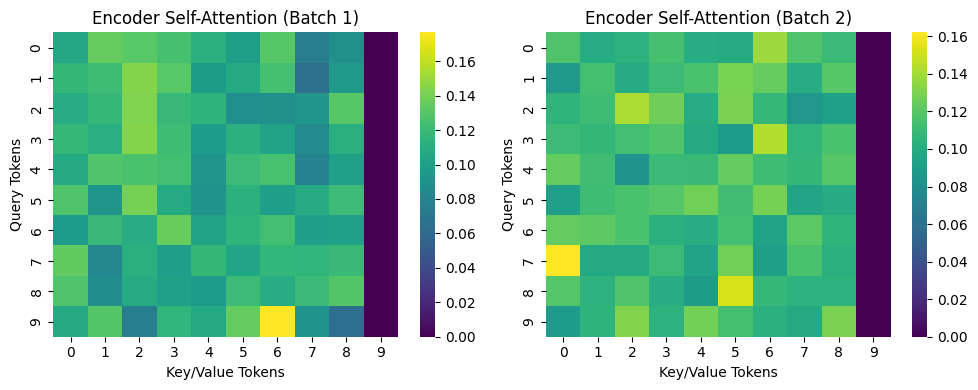


--- Decoder Self-Attention (with padding and causal mask) ---
Toy Decoder Input Shape: torch.Size([2, 8, 32])
Toy Decoder Self-Attention Output Shape: torch.Size([2, 8, 32])
Toy Decoder Self-Attention Weights Shape: torch.Size([2, 4, 8, 8])
Decoder self-attention outputs generated successfully.


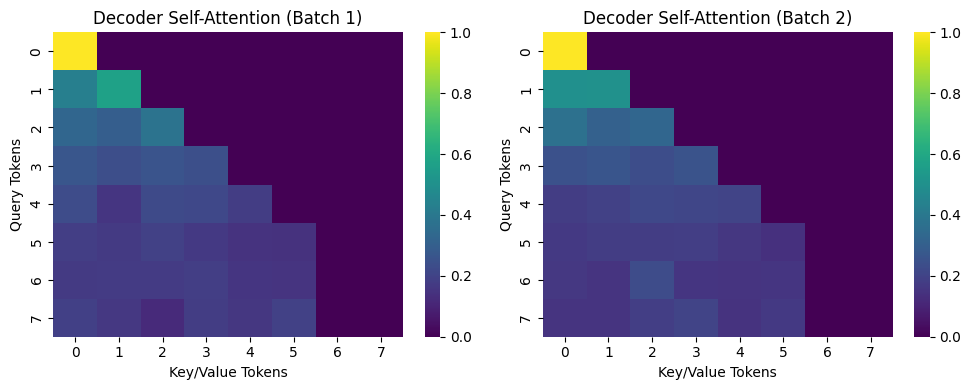


--- Decoder Cross-Attention ---
Toy Decoder Query Input Shape: torch.Size([2, 8, 32])
Toy Encoder Key/Value Input Shape: torch.Size([2, 10, 32])
Toy Decoder Cross-Attention Output Shape: torch.Size([2, 8, 32])
Toy Decoder Cross-Attention Weights Shape: torch.Size([2, 4, 8, 10])
Decoder cross-attention outputs generated successfully.

Cross-Attention Weights (Batch 1):
[[0.11148946 0.11142839 0.11101532 0.11159262 0.11160178 0.11109009
  0.11087048 0.11059274 0.11031912 0.        ]
 [0.11141279 0.11137024 0.11095819 0.11149949 0.11150178 0.11112621
  0.11099962 0.11066867 0.11046301 0.        ]
 [0.11110879 0.11117779 0.11109365 0.11117026 0.11115681 0.11118034
  0.11101636 0.11113198 0.11096404 0.        ]
 [0.11121996 0.11117451 0.11108725 0.11112636 0.11113657 0.11107482
  0.11116535 0.11109114 0.11092405 0.        ]
 [0.11120495 0.11120075 0.11107581 0.11117367 0.11119267 0.11111512
  0.11110625 0.1110686  0.11086218 0.        ]
 [0.11121606 0.11125854 0.11104902 0.11128747 0.11129

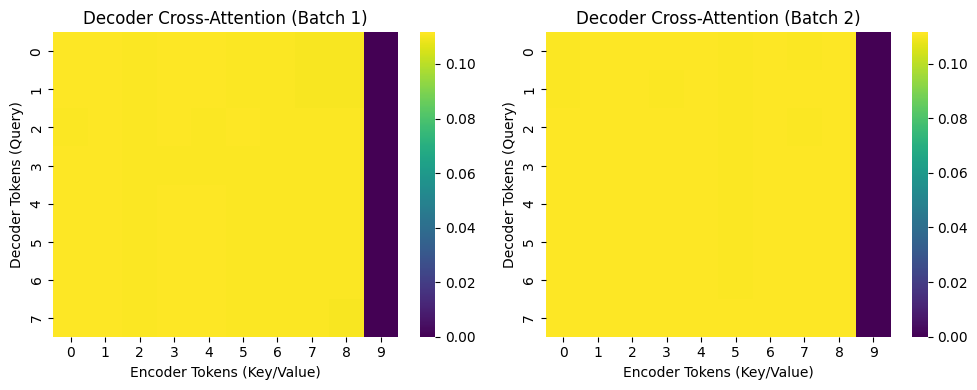

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Helper function to generate padding mask
def _generate_padding_mask(batch_size, seq_len, num_pad_tokens, device='cpu'):
    # Initialize a mask with all ones (True), meaning all tokens are active
    mask = torch.ones(batch_size, seq_len, dtype=torch.bool, device=device)
    # If there are padding tokens, set their positions to False
    if num_pad_tokens > 0:
        mask[:, -num_pad_tokens:] = False
    # Unsqueeze to get the shape (batch_size, 1, 1, seq_len) or (batch_size, 1, query_seq_len, key_seq_len)
    # This shape allows for proper broadcasting when multiplied with attention scores.
    return mask.unsqueeze(1).unsqueeze(2)

# Define hyperparameters for the toy example
hidden_size = 32
num_attention_heads = 4
batch_size = 2
encoder_seq_len = 10 # Example encoder sequence length
decoder_seq_len = 8  # Example decoder sequence length

print("--- Toy Example for MultiHeadAttentionLayer ---")

# --- 1. Encoder Self-Attention Toy Example ---
print("\n--- Encoder Self-Attention ---")
# Create random hidden states representing the output of an encoder's embedding layer
toy_encoder_hidden_states = torch.randn(batch_size, encoder_seq_len, hidden_size)

# Generate an encoder padding mask: assuming the last token is a pad token
# This mask will be used for both query and key/value in self-attention.
# Shape: (batch_size, 1, 1, encoder_seq_len)
encoder_padding_mask = _generate_padding_mask(batch_size, encoder_seq_len, num_pad_tokens=1)

encoder_self_attention_layer = MultiHeadAttentionLayer(hidden_size, num_attention_heads)

# For self-attention, query, key, and value are all the same input
encoder_output, encoder_attn_weights = encoder_self_attention_layer.forward(
    toy_encoder_hidden_states, toy_encoder_hidden_states, toy_encoder_hidden_states,
    mask=encoder_padding_mask
)

print(f"Toy Encoder Input Shape: {toy_encoder_hidden_states.shape}")
print(f"Toy Encoder Self-Attention Output Shape: {encoder_output.shape}")
print(f"Toy Encoder Self-Attention Weights Shape: {encoder_attn_weights.shape}")
print(f"Encoder Padding Mask (first batch item): {encoder_padding_mask[0].squeeze().cpu().numpy()}") # Added print statement
print("Encoder self-attention outputs generated successfully.")

# Plotting Encoder Self-Attention Weights
plt.figure(figsize=(10, 4))
for i in range(batch_size):
    plt.subplot(1, batch_size, i + 1)
    # Average attention weights across heads for visualization
    avg_attn_weights = encoder_attn_weights[i].mean(dim=0).detach().cpu().numpy()
    sns.heatmap(avg_attn_weights, cmap='viridis', cbar=True, annot=False, fmt=".2f")
    plt.title(f'Encoder Self-Attention (Batch {i+1})')
    plt.xlabel('Key/Value Tokens')
    plt.ylabel('Query Tokens')
plt.tight_layout()
plt.show()

# --- 2. Decoder Self-Attention Toy Example ---
print("\n--- Decoder Self-Attention (with padding and causal mask) ---")
# Create random hidden states representing the output of a decoder's embedding layer
toy_decoder_hidden_states = torch.randn(batch_size, decoder_seq_len, hidden_size)

# Generate a decoder padding mask: assuming the last two tokens are pad tokens
decoder_padding_mask = _generate_padding_mask(batch_size, decoder_seq_len, num_pad_tokens=2)

# Create a causal (look-ahead) mask:
# A lower triangular matrix ensures tokens only attend to themselves and previous tokens.
# Shape: (1, 1, decoder_seq_len, decoder_seq_len)
causal_mask = torch.tril(torch.ones(decoder_seq_len, decoder_seq_len, dtype=torch.bool, device='cpu'))
causal_mask = causal_mask.unsqueeze(0).unsqueeze(1) # (1, 1, seq_len, seq_len)

# Combine padding mask and causal mask using logical AND
# This ensures both padding is masked AND future tokens are masked.
combined_decoder_self_attention_mask = decoder_padding_mask & causal_mask

decoder_self_attention_layer = MultiHeadAttentionLayer(hidden_size, num_attention_heads)

decoder_self_attn_output, decoder_self_attn_weights = decoder_self_attention_layer.forward(
    toy_decoder_hidden_states, toy_decoder_hidden_states, toy_decoder_hidden_states,
    mask=combined_decoder_self_attention_mask
)

print(f"Toy Decoder Input Shape: {toy_decoder_hidden_states.shape}")
print(f"Toy Decoder Self-Attention Output Shape: {decoder_self_attn_output.shape}")
print(f"Toy Decoder Self-Attention Weights Shape: {decoder_self_attn_weights.shape}")
print("Decoder self-attention outputs generated successfully.")

# Plotting Decoder Self-Attention Weights
plt.figure(figsize=(10, 4))
for i in range(batch_size):
    plt.subplot(1, batch_size, i + 1)
    # Average attention weights across heads for visualization
    avg_attn_weights = decoder_self_attn_weights[i].mean(dim=0).detach().cpu().numpy()
    sns.heatmap(avg_attn_weights, cmap='viridis', cbar=True, annot=False, fmt=".2f")
    plt.title(f'Decoder Self-Attention (Batch {i+1})')
    plt.xlabel('Key/Value Tokens')
    plt.ylabel('Query Tokens')
plt.tight_layout()
plt.show()

# --- 3. Decoder Cross-Attention Toy Example ---
print("\n--- Decoder Cross-Attention ---")
# Query comes from the decoder's self-attention output
# Key and Value come from the encoder's output
decoder_cross_attention_layer = MultiHeadAttentionLayer(hidden_size, num_attention_heads)

# The mask for cross-attention is the encoder's padding mask.
# This prevents the decoder from attending to padding in the encoder's output.
cross_attn_output, cross_attn_weights = decoder_cross_attention_layer.forward(
    decoder_self_attn_output, encoder_output, encoder_output,
    mask=encoder_padding_mask # Mask here applies to the K/V (encoder_output)
)

print(f"Toy Decoder Query Input Shape: {decoder_self_attn_output.shape}")
print(f"Toy Encoder Key/Value Input Shape: {encoder_output.shape}")
print(f"Toy Decoder Cross-Attention Output Shape: {cross_attn_output.shape}")
print(f"Toy Decoder Cross-Attention Weights Shape: {cross_attn_weights.shape}")
print("Decoder cross-attention outputs generated successfully.")

# Plotting Decoder Cross-Attention Weights
plt.figure(figsize=(10, 4))
for i in range(batch_size):
    plt.subplot(1, batch_size, i + 1)
    # Average attention weights across heads for visualization
    avg_attn_weights = cross_attn_weights[i].mean(dim=0).detach().cpu().numpy()
    print(f"\nCross-Attention Weights (Batch {i+1}):\n{avg_attn_weights}") # Added print statement for matrix
    sns.heatmap(avg_attn_weights, cmap='viridis', cbar=True, annot=False, fmt=".2f")
    plt.title(f'Decoder Cross-Attention (Batch {i+1})')
    plt.xlabel('Encoder Tokens (Key/Value)')
    plt.ylabel('Decoder Tokens (Query)')
plt.tight_layout()
plt.show()

Before moving on to the other modules, you should also implement a sanity check for your attention implementation:
1. Check the dimensions of the output of the layer and
2. Plot the attention weights to some toy embedding inputs.


You can assume that the last token in the encoder and the last two tokens in the decoder are pad tokens.

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

class EncoderDecoderModel(nn.Module):
  def __init__(self, encoder_vocab_size, decoder_vocab_size, hidden_size,
               num_attention_heads, num_encoder_layers, num_decoder_layers,
               intermediate_size, max_sequence_length, hidden_dropout_prob,
               pad_token_id=0):
    super().__init__()

    self.pad_token_id = pad_token_id
    self.max_sequence_length = max_sequence_length

    # 1. Embeddings
    self.embeddings = EmbeddingData(
        encoder_vocab_size=encoder_vocab_size,
        decoder_vocab_size=decoder_vocab_size,
        hidden_size=hidden_size,
        max_seq_length=max_sequence_length
    )

    # 2. Encoder Stack
    self.encoder_layers = nn.ModuleList([
        TransformerBlock(
            hidden_size=hidden_size,
            num_attention_heads=num_attention_heads,
            intermediate_size=intermediate_size,
            dropout_prob=hidden_dropout_prob,
            is_decoder=False
        ) for _ in range(num_encoder_layers)
    ])

    # 3. Decoder Stack
    self.decoder_layers = nn.ModuleList([
        TransformerBlock(
            hidden_size=hidden_size,
            num_attention_heads=num_attention_heads,
            intermediate_size=intermediate_size,
            dropout_prob=hidden_dropout_prob,
            is_decoder=True
        ) for _ in range(num_decoder_layers)
    ])

    # 4. Final output layer for logits
    # This projects the decoder's final hidden state to the decoder's vocabulary size
    self.output_layer = nn.Linear(hidden_size, decoder_vocab_size)

  def _create_padding_mask(self, input_ids):
    # Create a boolean mask where True indicates a non-padding token (active)
    # and False indicates a padding token (to be masked out).
    # input_ids shape: (batch_size, seq_len)
    # output mask shape: (batch_size, 1, 1, seq_len) for broadcasting
    padding_mask = (input_ids != self.pad_token_id).unsqueeze(1).unsqueeze(2)
    return padding_mask

  def _create_causal_mask(self, seq_len, device):
    # Create a lower triangular matrix for causal masking
    # mask shape: (1, 1, seq_len, seq_len)
    causal_mask = torch.tril(torch.ones(seq_len, seq_len, dtype=torch.bool, device=device))
    return causal_mask.unsqueeze(0).unsqueeze(1)

  def forward(self, encoder_input_ids, decoder_input_ids, return_cross_attention_weights: bool = False):
    # Ensure inputs are within max_sequence_length
    if encoder_input_ids.size(1) > self.max_sequence_length or \
       decoder_input_ids.size(1) > self.max_sequence_length:
        raise ValueError(f"Input sequence length exceeds max_sequence_length ({self.max_sequence_length})")

    # 1. Create masks
    # Encoder padding mask (for self-attention and cross-attention KV)
    encoder_padding_mask = self._create_padding_mask(encoder_input_ids)

    # Decoder self-attention mask (combining padding and causality)
    decoder_padding_mask = self._create_padding_mask(decoder_input_ids)
    decoder_causal_mask = self._create_causal_mask(decoder_input_ids.size(1), decoder_input_ids.device)
    # Combined mask: True only where both are True (non-pad and non-future)
    decoder_self_attention_mask = decoder_padding_mask & decoder_causal_mask

    # 2. Encoder Pass
    encoder_hidden_states = self.embeddings.encoder_embed(encoder_input_ids)
    for encoder_layer in self.encoder_layers:
      encoder_hidden_states = encoder_layer(
          hidden_states=encoder_hidden_states,
          attention_mask=encoder_padding_mask # Encoder self-attention mask
      )

    # 3. Decoder Pass
    decoder_hidden_states = self.embeddings.decoder_embed(decoder_input_ids)
    all_cross_attention_weights = []

    for decoder_layer in self.decoder_layers:
      # Call the decoder layer. It will return (hidden_states,) or (hidden_states, cross_attn_weights)
      # based on the return_attention_weights flag passed to it.
      layer_output = decoder_layer(
          hidden_states=decoder_hidden_states,
          attention_mask=decoder_self_attention_mask, # Decoder self-attention mask
          encoder_hidden_states=encoder_hidden_states, # Encoder output for cross-attention
          encoder_attention_mask=encoder_padding_mask, # Encoder padding mask for cross-attention KV
          return_attention_weights=return_cross_attention_weights
      )

      # Unpack based on whether attention weights are expected
      if return_cross_attention_weights:
        decoder_hidden_states, cross_attn_weights = layer_output
        all_cross_attention_weights.append(cross_attn_weights)
      else:
        decoder_hidden_states = layer_output # Only hidden_states are returned

    # 4. Final Logits
    logits = self.output_layer(decoder_hidden_states)

    if return_cross_attention_weights:
      return logits, all_cross_attention_weights
    return logits

# Instantiate the model with specified hyperparameters
hidden_size = 32
intermediate_size = 128 # 32 * 4
num_attention_heads = 4
num_encoder_layers = 3
num_decoder_layers = 3
max_sequence_length = 32 # From problem description
hidden_dropout_prob = 0.1

# Vocabulary sizes from tokenizers
encoder_vocab_size = french_tokenizer.vocab_size
decoder_vocab_size = english_tokenizer.vocab_size
pad_token_id = english_tokenizer.pad_token_id # Assuming pad_token_id is the same for both, typically 0 or specific to tokenizer

# Instantiate the model
nmt_model = EncoderDecoderModel(
    encoder_vocab_size=encoder_vocab_size,
    decoder_vocab_size=decoder_vocab_size,
    hidden_size=hidden_size,
    num_attention_heads=num_attention_heads,
    num_encoder_layers=num_encoder_layers,
    num_decoder_layers=num_decoder_layers,
    intermediate_size=intermediate_size,
    max_sequence_length=max_sequence_length,
    hidden_dropout_prob=hidden_dropout_prob,
    pad_token_id=pad_token_id
)

print("EncoderDecoderModel initialized successfully!")
print(f"Total parameters: {sum(p.numel() for p in nmt_model.parameters() if p.requires_grad)}")

EncoderDecoderModel initialized successfully!
Total parameters: 401536


## Train the model

You should implement the logic for your model to train on the parallel tokenized corpus. Before you start training models, you should implement and test the model and its sub-modules, especially the attention.


Use these hyperparameters for your training loop.
* batch_size: 32
* optimizer: Adam (default betas)
* learning_rate: 1e-3
* max_epochs: 15
* log_every: 10 steps
* valid_niter: 100 steps
* loss: cross-entropy, no label smoothing
* loss normalization: per token

Set a random seed, so you obtain the same output model if you run this cell again. With a reasonable implementation, this should take about 16 minutes on CPU / 3 minutes on GPU and you should achieve a validation perplexity of below 10. Note that different implementation and variation across different colab cpus may yield different speeds!

In [20]:
import torch
from torch.utils.data import DataLoader
from transformers import DataCollatorForSeq2Seq # Changed from DataCollatorWithPadding
import numpy as np
import math

# --- 1. Set Random Seed for Reproducibility ---
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# --- 2. Device Configuration ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
nmt_model.to(device)

# --- 3. Hyperparameters for Training ---
batch_size = 32
learning_rate = 1e-3
max_epochs = 15
log_every_n_steps = 10
valid_every_n_steps = 100

# --- 4. Data Collator and DataLoaders ---
# The DataCollatorForSeq2Seq will dynamically pad our batches to the longest sequence in the batch
# It correctly handles padding for both input_ids (using the provided tokenizer) and labels (defaulting to -100).

data_collator = DataCollatorForSeq2Seq(
    tokenizer=french_tokenizer, # Use French tokenizer for padding input_ids
    padding='longest',
    max_length=max_sequence_length,
    label_pad_token_id=-100 # This is the default, but explicitly stating for clarity. -100 is ignored by CrossEntropyLoss
)

train_dataloader = DataLoader(
    tokenized_train_dataset,
    shuffle=True,
    batch_size=batch_size,
    collate_fn=data_collator
)
val_dataloader = DataLoader(
    tokenized_val_dataset,
    shuffle=False,
    batch_size=batch_size,
    collate_fn=data_collator
)

# --- 5. Loss Function and Optimizer ---
# Loss normalization: per token. CrossEntropyLoss with ignore_index handles this.
loss_fn = nn.CrossEntropyLoss(ignore_index=-100) # -100 is the default for label_pad_token_id
optimizer = torch.optim.Adam(nmt_model.parameters(), lr=learning_rate)

# --- 6. Training Loop ---
print("\nStarting training...")
global_step = 0
best_val_perplexity = float('inf')

for epoch in range(max_epochs):
    nmt_model.train() # Set model to training mode
    total_train_loss = 0
    total_train_tokens = 0

    for step, batch in enumerate(train_dataloader):
        global_step += 1

        # Move batch to device
        encoder_input_ids = batch["input_ids"].to(device)
        # The attention_mask for encoder input_ids is automatically handled by DataCollatorForSeq2Seq
        # and is available in batch["attention_mask"]

        labels = batch["labels"].to(device)

        # Prepare decoder_input_ids and actual labels for loss calculation
        # decoder_input_ids: labels shifted right. The BOS token (often <s> or 1) should be present at the start of labels.
        # We remove the last token from labels to get decoder input (teacher forcing).
        decoder_input_ids = labels[:, :-1].contiguous()

        # Replace -100 (label padding) with actual pad_token_id for embedding layer
        decoder_input_ids[decoder_input_ids == -100] = nmt_model.pad_token_id

        # Actual labels for loss: shifted left (remove the BOS token, keep EOS). This is what the model should predict.
        true_labels = labels[:, 1:].contiguous()

        optimizer.zero_grad()

        # Forward pass
        logits = nmt_model(
            encoder_input_ids=encoder_input_ids,
            decoder_input_ids=decoder_input_ids
        )

        # Reshape for CrossEntropyLoss: (N, C) for input, (N) for target
        # We only care about the predictions for the actual tokens in true_labels (non-padding, non-BOS)
        active_logits = logits.view(-1, nmt_model.output_layer.out_features)
        active_labels = true_labels.view(-1)

        loss = loss_fn(active_logits, active_labels)
        loss.backward()
        optimizer.step()

        # Count active tokens for loss normalization (excluding -100 padding)
        num_active_tokens = (active_labels != -100).sum().item()
        total_train_loss += loss.item() * num_active_tokens
        total_train_tokens += num_active_tokens

        # Log training progress
        if global_step % log_every_n_steps == 0:
            avg_loss = total_train_loss / total_train_tokens if total_train_tokens > 0 else 0
            print(f"Epoch {epoch+1}, Step {step+1}/{len(train_dataloader)}: Train Loss = {avg_loss:.4f}")

        # Validation phase
        if global_step % valid_every_n_steps == 0:
            nmt_model.eval() # Set model to evaluation mode
            total_val_loss = 0
            total_val_tokens = 0

            with torch.no_grad():
                for val_step, val_batch in enumerate(val_dataloader):
                    val_encoder_input_ids = val_batch["input_ids"].to(device)
                    val_labels = val_batch["labels"].to(device)

                    val_decoder_input_ids = val_labels[:, :-1].contiguous()
                    # Replace -100 (label padding) with actual pad_token_id for embedding layer
                    val_decoder_input_ids[val_decoder_input_ids == -100] = nmt_model.pad_token_id

                    val_true_labels = val_labels[:, 1:].contiguous()

                    val_logits = nmt_model(
                        encoder_input_ids=val_encoder_input_ids,
                        decoder_input_ids=val_decoder_input_ids
                    )

                    val_active_logits = val_logits.view(-1, nmt_model.output_layer.out_features)
                    val_active_labels = val_true_labels.view(-1)

                    val_loss = loss_fn(val_active_logits, val_active_labels)

                    num_val_active_tokens = (val_active_labels != -100).sum().item()
                    total_val_loss += val_loss.item() * num_val_active_tokens
                    total_val_tokens += num_val_active_tokens

            avg_val_loss = total_val_loss / total_val_tokens if total_val_tokens > 0 else 0
            val_perplexity = math.exp(avg_val_loss) if avg_val_loss < float('inf') else float('inf')

            print(f"\n--- Validation after Step {global_step} ---")
            print(f"Validation Loss = {avg_val_loss:.4f}, Perplexity = {val_perplexity:.2f}")

            if val_perplexity < best_val_perplexity:
                best_val_perplexity = val_perplexity
                print("New best validation perplexity! Saving model...")
                # You might want to save the model state here
                # torch.save(nmt_model.state_dict(), "best_nmt_model.pth")
            print("---------------------------------")

            nmt_model.train() # Switch back to training mode

    # End of epoch validation if not already done by valid_every_n_steps
    if global_step % valid_every_n_steps != 0:
        nmt_model.eval() # Set model to evaluation mode
        total_val_loss = 0
        total_val_tokens = 0

        with torch.no_grad():
            for val_step, val_batch in enumerate(val_dataloader):
                val_encoder_input_ids = val_batch["input_ids"].to(device)
                val_labels = val_batch["labels"].to(device)

                val_decoder_input_ids = val_labels[:, :-1].contiguous()
                # Replace -100 (label padding) with actual pad_token_id for embedding layer
                val_decoder_input_ids[val_decoder_input_ids == -100] = nmt_model.pad_token_id

                val_true_labels = val_labels[:, 1:].contiguous()

                val_logits = nmt_model(
                    encoder_input_ids=val_encoder_input_ids,
                    decoder_input_ids=val_decoder_input_ids
                )

                val_active_logits = val_logits.view(-1, nmt_model.output_layer.out_features)
                val_active_labels = val_true_labels.view(-1)

                val_loss = loss_fn(val_active_logits, val_active_labels)

                num_val_active_tokens = (val_active_labels != -100).sum().item()
                total_val_loss += val_loss.item() * num_val_active_tokens
                total_val_tokens += num_val_active_tokens

        avg_val_loss = total_val_loss / total_val_tokens if total_val_tokens > 0 else 0
        val_perplexity = math.exp(avg_val_loss) if avg_val_loss < float('inf') else float('inf')

        print(f"\n--- Validation after Epoch {epoch+1} ---")
        print(f"Validation Loss = {avg_val_loss:.4f}, Perplexity = {val_perplexity:.2f}")

        if val_perplexity < best_val_perplexity:
            best_val_perplexity = val_perplexity
            print("New best validation perplexity! Saving model...")
            # torch.save(nmt_model.state_dict(), "best_nmt_model.pth")
        print("---------------------------------")

        nmt_model.train() # Switch back to training mode

print("\nTraining complete!")
print(f"Best Validation Perplexity: {best_val_perplexity:.2f}")

Using device: cpu

Starting training...
Epoch 1, Step 10/272: Train Loss = 7.6957
Epoch 1, Step 20/272: Train Loss = 7.3780
Epoch 1, Step 30/272: Train Loss = 7.1113
Epoch 1, Step 40/272: Train Loss = 6.8721
Epoch 1, Step 50/272: Train Loss = 6.6536
Epoch 1, Step 60/272: Train Loss = 6.4461
Epoch 1, Step 70/272: Train Loss = 6.2443
Epoch 1, Step 80/272: Train Loss = 6.0557
Epoch 1, Step 90/272: Train Loss = 5.8840
Epoch 1, Step 100/272: Train Loss = 5.7213

--- Validation after Step 100 ---
Validation Loss = 4.0304, Perplexity = 56.28
New best validation perplexity! Saving model...
---------------------------------
Epoch 1, Step 110/272: Train Loss = 5.5657
Epoch 1, Step 120/272: Train Loss = 5.4284
Epoch 1, Step 130/272: Train Loss = 5.3015
Epoch 1, Step 140/272: Train Loss = 5.1876
Epoch 1, Step 150/272: Train Loss = 5.0787
Epoch 1, Step 160/272: Train Loss = 4.9806
Epoch 1, Step 170/272: Train Loss = 4.8870
Epoch 1, Step 180/272: Train Loss = 4.8032
Epoch 1, Step 190/272: Train Loss

## Evaluate the model

You have now trained a seq2seq model for the NMT task. Now evaluate the model on the test set by generating translations with beam search and comparing them to the gold translations using the corpus-level BLEU score from `nltk.translate.bleu_score.corpus_bleu`.

Use these hyperparameters for your evaluations.
* beam_width: 5
* max_decoding_length: 32

In [22]:
import torch
import torch.nn.functional as F
from tqdm.notebook import tqdm # For progress bar
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize
import re
import nltk

nltk.download('punkt_tab') # Download the missing NLTK resource

# Helper function for cleaning text before BLEU calculation
def clean_text(text):
    # Lowercase, remove punctuation, normalize whitespace
    text = text.lower()
    # Remove specific special tokens like '▁' if they are not part of actual words
    text = text.replace('▁', '')
    text = re.sub(r'[^"\w\s]', '', text) # Remove punctuation, except for single quotes and dashes which might be part of words
    text = re.sub(r'\s+', ' ', text).strip() # Normalize whitespace
    return text

# Function to translate a single sentence using beam search
def translate_sentence_beam_search(model, encoder_input_ids_single, max_length, beam_width, bos_token_id, eos_token_id, pad_token_id, device):
    model.eval() # Set model to evaluation mode

    with torch.no_grad():
        # encoder_input_ids_single should be (1, src_len)
        encoder_input_ids_single = encoder_input_ids_single.to(device)

        # Initial beam: list of (sequence_tensor, score)
        # Each sequence_tensor is (1, current_seq_len)
        beam_hypotheses = [(torch.tensor([[bos_token_id]], dtype=torch.long, device=device), 0.0)]

        for _ in range(max_length): # Decode up to max_length
            all_candidates = []

            for seq_tensor, score in beam_hypotheses:
                # If this sequence has already ended with EOS, it cannot be expanded further
                if seq_tensor[0, -1].item() == eos_token_id:
                    all_candidates.append((seq_tensor, score))
                    continue

                # Get logits for the next token
                # model expects encoder_input_ids and decoder_input_ids
                logits = model(
                    encoder_input_ids=encoder_input_ids_single,
                    decoder_input_ids=seq_tensor
                )
                next_token_logits = logits[:, -1, :] # Logits for the last predicted token, shape (1, vocab_size)
                next_token_log_probs = F.log_softmax(next_token_logits, dim=-1) # shape (1, vocab_size)

                # Get top K candidates for the next token from this beam
                top_k_log_probs, top_k_tokens = next_token_log_probs[0].topk(beam_width) # both (beam_width) tensors

                for i in range(beam_width):
                    token = top_k_tokens[i].unsqueeze(0).unsqueeze(0) # (1, 1) tensor for the next token
                    log_prob = top_k_log_probs[i].item()

                    new_seq = torch.cat([seq_tensor, token], dim=-1)
                    new_score = score + log_prob
                    all_candidates.append((new_seq, new_score))

            # Sort all candidates (across all expanded beams) by score and select top beam_width
            # Length normalization: average log probability (excluding BOS token for length calculation)
            all_candidates.sort(key=lambda x: x[1] / (x[0].shape[1] - 1) if x[0].shape[1] > 1 else -float('inf'), reverse=True)
            beam_hypotheses = all_candidates[:beam_width]

            # Early stopping: if all hypotheses in the beam have generated EOS
            if all(seq[0, -1].item() == eos_token_id for seq, _ in beam_hypotheses):
                break

        # After loop, pick the best hypothesis from the current beam_hypotheses
        if not beam_hypotheses: # Fallback if something went wrong and beam_hypotheses is empty
            return torch.tensor([bos_token_id], dtype=torch.long, device='cpu')

        best_sequence_tensor = beam_hypotheses[0][0].squeeze(0).cpu() # Get the sequence tensor, remove batch dim, move to CPU

        # Post-processing: Remove BOS, EOS and padding tokens
        # Remove BOS token if it's the first one
        if best_sequence_tensor.numel() > 0 and best_sequence_tensor[0].item() == bos_token_id:
            best_sequence_tensor = best_sequence_tensor[1:]

        # Find the first EOS token and truncate everything after it
        if eos_token_id in best_sequence_tensor:
            eos_idx = (best_sequence_tensor == eos_token_id).nonzero(as_tuple=True)[0][0].item()
            best_sequence_tensor = best_sequence_tensor[:eos_idx]

        # Remove any remaining padding tokens (should be handled by EOS truncation, but as a safeguard)
        best_sequence_tensor = best_sequence_tensor[best_sequence_tensor != pad_token_id]

        return best_sequence_tensor


# Evaluation hyperparameters
beam_width = 5
max_decoding_length = 32

# Get special token IDs from the English tokenizer
bos_token_id = english_tokenizer.bos_token_id
eos_token_id = english_tokenizer.eos_token_id
pad_token_id = english_tokenizer.pad_token_id

# Device configuration (ensuring model is on the correct device)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nmt_model.to(device)

predicted_sentences = []
reference_sentences = []

print("Starting evaluation on the test set...")

# Iterate directly over the tokenized_test_dataset for single-example inference
for i in tqdm(range(len(tokenized_test_dataset)), desc="Translating test set"):
    example = tokenized_test_dataset[i]

    # Encoder input: Add batch dimension (1, seq_len)
    encoder_input_ids = torch.tensor(example["input_ids"], dtype=torch.long).unsqueeze(0)

    # Reference labels: Filter out padding tokens (-100)
    gold_labels_tokens = [token for token in example["labels"] if token != -100]

    # Translate using beam search
    predicted_token_ids = translate_sentence_beam_search(
        nmt_model,
        encoder_input_ids,
        max_decoding_length,
        beam_width,
        bos_token_id,
        eos_token_id,
        pad_token_id,
        device
    )

    # Decode predicted tokens back to text
    predicted_text = english_tokenizer.decode(predicted_token_ids, skip_special_tokens=True)
    # Decode reference tokens back to text
    reference_text = english_tokenizer.decode(gold_labels_tokens, skip_special_tokens=True)

    # Append cleaned and tokenized versions for BLEU calculation
    predicted_sentences.append(word_tokenize(clean_text(predicted_text)))
    reference_sentences.append([word_tokenize(clean_text(reference_text))]) # corpus_bleu expects list of lists for references

# Calculate corpus BLEU score
# Use SmoothingFunction().method1 for more robust BLEU calculation with short sentences
smoothie = SmoothingFunction().method1

# Filter out empty predictions or references that could cause issues with BLEU
filtered_predicted_sentences = []
filtered_reference_sentences = []

for pred, refs in zip(predicted_sentences, reference_sentences):
    if pred and refs and refs[0]: # Ensure prediction and reference are not empty after tokenization
        filtered_predicted_sentences.append(pred)
        filtered_reference_sentences.append(refs)

if not filtered_predicted_sentences:
    print("No valid predictions to calculate BLEU score.")
    bleu_score = 0.0
else:
    print(f"Calculating BLEU score for {len(filtered_predicted_sentences)} examples...")
    bleu_score = corpus_bleu(filtered_reference_sentences, filtered_predicted_sentences, smoothing_function=smoothie)

print(f"\nCorpus BLEU score on test set: {bleu_score * 100:.2f}")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Starting evaluation on the test set...


Translating test set:   0%|          | 0/486 [00:00<?, ?it/s]

Calculating BLEU score for 486 examples...

Corpus BLEU score on test set: 34.81


Look at some examples. What do you think of the quality of the translations? Are these grammatical English sentences? Can you identify any common mistakes?

In [44]:
i = 98
print(predicted_sentences[i])
print(reference_sentences[i])

['we', 're', 'staying']
[['we', 're', 'buying']]


# Questions

**(b) (2 points)**

- **(i)
    What vocabulary size are we using for the source and target language?**

- **(ii)
    Approximately how many source and target tokens are on average contained in a training batch? What proportion of these tokens are `<pad>` tokens on average?**


TODO: ANSWER THE QUESTION HERE (DOUBLE-CLICK TO EDIT)

Code for sub-part (b)


**(c) (2 points)
Manually look at some results and compare them with the gold answers. What do you think of the quality of the translations? Are these grammatical English sentences? Can you identify any common mistakes?**

TODO: ANSWER THE QUESTION HERE (DOUBLE-CLICK TO EDIT)



**(d) (10 points) Extract and visualize the *cross-attention* weights from the *last decoder layer*, averaged across all attention heads. This should produce a single 2-D heatmap per example, where the rows correspond to the generated English (target) tokens and the columns correspond to the French (source) tokens.**

Produce attention heatmaps for the following two French sentences:
* Le chat noir est assis sur le tapis rouge.
* Elle n'a pas encore pris une décision importante concernant son avenir.

For each example, answer the following questions:
* Does the attention pattern resemble a word-level alignment between the source and target sentences? Where does it deviate from a diagonal pattern, and why might that be the case? *(Hint: Consider word order differences between French and English.)*
* Does the attention heatmap reveal anything about how the model handles the translation? For instance, are there tokens where attention is diffuse or concentrated, and can you relate this to the structure of the sentence?


TODO: ANSWER THE QUESTION HERE (DOUBLE-CLICK TO EDIT)

Code for sub-part (d)

# LLM Prompts

If you used an AI tool to complete any part of this assignment, please paste all prompts you used to produce your final code/responses in the box below and answer the following reflection question.

Prompts Used:
*   can you create the multihead attention layer class according to the instructions in the assignment
*   I think I will want to create separate classes for the encoder transformer block and the decoder transformer block, in order to increase readability. is this a good idea? (don't write any code)
*  implement the evaluation of the model



**Reflection: What parts of the AI generated output required modification or improvement? Describe the feedback you gave the tool to produce your final output or any changes you had to make on your own.**

TODO: ANSWER THE QUESTION HERE (DOUBLE-CLICK TO EDIT)